<a href="https://colab.research.google.com/github/msnaspers/ml-pg2025/blob/main/MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<span style="color: lightblue">

# ML - PROJEKT ZALICZENIOWY
## 1. Project overview
### 1.1. Konfiguracja środowiska i parametrów

<span>

In [ ]:
import sys
print(sys.executable)
print(sys.version)

/Users/Marcin_Sierakowski/Downloads/marcin/bin/python
3.9.6 (default, Jan  9 2026, 11:03:41) 
[Clang 17.0.0 (clang-1700.6.4.2)]


In [ ]:
# Import bibliotek:
import hashlib
import kagglehub
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import pathlib
import pandas as pd
import tensorflow as tf
from collections import Counter

from PIL import Image
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from tensorflow.keras import models, layers



In [ ]:
# Weryfikacja, czy środowisko wykorzystuje GPU
print(f"GPU: {tf.config.list_physical_devices('GPU')}")


GPU: []


In [ ]:
# Flaga określająca, czy skrypt ma działać lokalnie
run_locally = True

# Liczba epok do trenowania modelu
num_of_epochs = 30

In [ ]:
#funkcje, ktore wrzucimy do folderku utils:

In [ ]:
# Zamiana batched datasetu na pandas DataFrame:
def batched_dataset_to_df(ds):
    return pd.DataFrame([
        (p.numpy().decode(), int(np.argmax(y.numpy())))
        for (x, y), ps in ds
        for p, y in zip(ps, y)
    ], columns=["path", "label"])

# Sprawdzenie balansu rozkładu klas w zbiorze danych
def check_balance(df, target):
    df_percentage = df[target].value_counts(normalize=True) * 100
    num = df_percentage.max()
    if num == 25:
        descr = "Dane są idealnie zrównoważone."
    elif num <= 35:
        descr = "Dane są dobrze zrównoważone."
    elif num <= 45:
        descr = "Lekka nierównowaga – akceptowalna."
    elif num <= 55:
        descr = "Umiarkowana nierównowaga – warto monitorować."
    else:
        descr = "Silna nierównowaga – zalecane balansowanie danych."
    return descr

# Analiza błędów

def collect_errors(model, dataset, normalize=False):
    errors = []

    for x_batch, y_batch in dataset:
        preds = model.predict(x_batch, verbose=0)

        for img, true_oh, pred_probs in zip(x_batch.numpy(), y_batch.numpy(), preds):
            true_label = np.argmax(true_oh)
            pred_label = np.argmax(pred_probs)

            if true_label != pred_label:
                errors.append({
                    "image": img / 255.0 if normalize else img,
                    "true": true_label,
                    "predicted": pred_label,
                    "confidence": float(pred_probs[pred_label])
                })

    return errors

# Wczytanie danych z Kaggle i utworzenie datasetów treningowego i testowego:
def data_reader(path: str, img_size=(150, 150), batch_size=None):
    dataset_path = kagglehub.dataset_download(path)
    train_dir = os.path.join(dataset_path, "Training")
    test_dir = os.path.join(dataset_path, "Testing")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=False, ### na razie tak zamiast False zeby sciezki podpiac
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=False,
    )

    train_paths = tf.data.Dataset.from_tensor_slices(train_ds.file_paths)
    test_paths = tf.data.Dataset.from_tensor_slices(test_ds.file_paths)

    enriched_train_ds = tf.data.Dataset.zip((train_ds, train_paths))
    enriched_test_ds = tf.data.Dataset.zip((test_ds, test_paths))
    full_ds=enriched_train_ds.concatenate(enriched_test_ds)

    categories = set(train_ds.class_names+test_ds.class_names)

    return (full_ds, categories, train_ds, test_ds)


# Zamiana datasetu na DataFrame (bez batching)
def dataset_to_df(ds):
    return pd.DataFrame([
        (path.numpy().decode(), int(np.argmax(label.numpy())))
        for (image, label), path in ds
    ], columns=["path", "label"])

# Definicja modelu opartego na architekturze EfficientNetB0 z wykorzystaniem transfer learningu
def effNet_model(num_classes=4, input_shape=(150, 150, 3)):

  base_model = tf.keras.applications.EfficientNetB0(
      weights="imagenet", # wczytujemy wstępnie wytrenowane wagi na zbiorze ImageNet
      include_top=False,  # usuwamy oryginalną warstwę klasyfikacyjną (1000 klas)
      input_shape=input_shape
  )

  base_model.trainable = False # zamrażamy wagi modelu bazowego, aby nie były aktualizowane podczas treningu

# Część klasyfikacyjna dopasowana do problemu
  x = base_model.output  # przekazujemy dane przez model bazowy (bez uczenia)
  x = layers.GlobalAveragePooling2D()(x)  # redukujemy mapy cech do jednego wektora
  x = layers.Dropout(0.3)(x)              # dodajemy dropout w celu redukcji przeuczenia
  outputs = layers.Dense(num_classes, activation="softmax")(x)  # warstwa wyjściowa dla klasyfikacji wieloklasowej

  return tf.keras.Model(inputs=base_model.input, outputs=outputs)


# Funkcja do wykrywania duplikatów obrazów w datasetach:
def find_image_duplicates(**kwargs):
    datasets = list(kwargs.values())
    def image_hash(image):
      image_bytes = tf.io.serialize_tensor(image)
      return hashlib.md5(image_bytes.numpy()).hexdigest()
    if not datasets:
        return {
            "Liczba wszystkich obrazów:": 0,
            "Liczba duplikatów:": 0,
            "Unikalne obrazy:": 0,
            "Duplikaty szczegóły:": []
        }

    full_ds = datasets[0]
    for ds in datasets[1:]:
        full_ds = full_ds.concatenate(ds)

    hash_to_path = {}
    duplicates = []
    total_images = 0

    for (img, _), path in full_ds:
      total_images += 1
      h = image_hash(img)
      path_str = path.numpy().decode()

      if h in hash_to_path:

          duplicates.append((path_str, hash_to_path[h]))
      else:

          hash_to_path[h] = path_str

    return {
        "Number of images": total_images,
        "Number of duplicates": len(duplicates),
        "Unique images": len(hash_to_path),
        "Duplicates details": duplicates
    }


#Funkcja do generowania tabeli metryk w markdown
import pandas as pd
from sklearn.metrics import f1_score

def generate_markdown_table(cnn_results, effNet_results):
    f1_cnn = f1_score(cnn_results["y_true"], cnn_results["y_pred"], average="macro")
    f1_effNet = f1_score(effNet_results["y_true"], effNet_results["y_pred"], average="macro")
    df = pd.DataFrame({
        "Metryka": [
            "Test Accuracy",
            "Test Loss",
            "Macro F1-Score",
            "Liczba parametrów ogółem",
            "Liczba parametrów trenowalnych",
            "Epoki do zatrzymania"
        ],
        "CNN": [
            f"{cnn_results['accuracy']:.2%}",
            f"{cnn_results['loss']:.4f}",
            f"{f1_cnn:.2%}",
            f"{cnn_results['params']:,}",
            f"{cnn_results['params_trainable']:,}",
            len(cnn_results['history'].history['accuracy'])
        ],
        "EfficientNetB0": [
            f"{effNet_results['accuracy']:.2%}",
            f"{effNet_results['loss']:.4f}",
            f"{f1_effNet:.2%}",
            f"{effNet_results['params']:,}",
            f"{effNet_results['params_trainable']:,}",
            len(effNet_results['history'].history['accuracy'])
        ]
    })

    return df.to_markdown(index=False)



# CNN model definition: konwolucje + pooling + dropout do ekstrakcji cech, Dense + Softmax do klasyfikacji
def model_cnn(num_classes=4, input_shape=(150, 150, 3)):
  inputs = tf.keras.Input(shape=input_shape)

  # Encoder
  x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2,2))(x)
  x = layers.Dropout(0.25)(x)

  x = layers.Conv2D(64,(3,3), activation="relu", padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2,2))(x)
  x = layers.Dropout(0.25)(x)

  x = layers.Conv2D(128,(3,3), activation="relu", padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2,2))(x)
  x = layers.Dropout(0.25)(x)

  # Klasyfikator
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation="relu")(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation="softmax")(x)

  return tf.keras.Model(inputs, outputs)

import matplotlib.pyplot as plt
import math


#Wykres accuracy
def plot_accuracy(histories, titles, suptitle):
    n = len(histories)

    fig, axes = plt.subplots(1, n, figsize=(7*n, 5))

    # gdy tylko 1 wykres
    if n == 1:
        axes = [axes]

    for ax, history, title in zip(axes, histories, titles):
        ax.plot(history.history["accuracy"], label="Train")
        ax.plot(history.history["val_accuracy"], label="Val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(suptitle, x=0.5)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Wykres rozkładu klas w DataFrame:
def plot_class_distribution(df, column="label_name", title="Rozkład klas"):
    labels = df[column].value_counts().index.tolist()
    colors = sns.color_palette("Blues", n_colors=len(labels))

    df[column].value_counts(normalize=True).plot(
        kind="pie",
        autopct="%1.1f%%",
        labels=labels,
        colors=colors,
        title=title,
        ylabel=""
    )

    plt.show()


# Wyświetlenie obrazów z błędnymi predykcjami o najwyższej pewności:
def plot_top_errors(errors, class_names, model_name="Model", n_show=8):

    # Sortowanie błędów po pewności malejąco
    errors_sorted = sorted(errors, key=lambda e: e["confidence"], reverse=True)

    n_show = min(n_show, len(errors_sorted))
    if n_show == 0:
        print(f"Brak błędów do wyświetlenia dla modelu {model_name}.")
        return

    # Tworzenie siatki wykresów (max 4 kolumn)
    n_cols = min(4, n_show)
    n_rows = (n_show + n_cols - 1) // n_cols

    plt.figure(figsize=(4*n_cols, 4*n_rows))

    for i in range(n_show):
        err = errors_sorted[i]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(err["image"])
        plt.title(
            f"Prawda: {class_names[err['true']]}\nPredykcja: {class_names[err['predicted']]} {err['confidence']:.0%}",
            color="red", fontsize=9
        )
        plt.axis("off")

    plt.suptitle(f"{model_name} - błędy z najwyższą pewnością", fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Wyprintowanie errorów:
def print_top_errors(errors, class_names, model_name, top_n=5):
    print(f"\n{'='*5} Najczęstsze pomyłki modelu {model_name} {'='*5}\n")
    print("Format: Prawda → Predykcja\n")  # wyjaśnienie dla czytelnika

    for i, ((true, pred), count) in enumerate(
        Counter((class_names[e["true"]], class_names[e["predicted"]]) for e in errors).most_common(top_n), 1
    ):
        print(f"{i}. {true} → {pred}: {count} przypadków")
    print("\n")  # odstęp po tabeli


# Usunięcie obrazów ze zbioru na podstawie listy ścieżek:
def remove_paths_from_dataset(dataset, paths_to_remove):
    paths_to_remove = tf.constant(paths_to_remove)
    def keep_fn(data, path):
        is_equal = tf.reduce_any(tf.equal(paths_to_remove, path))
        return tf.logical_not(is_equal)

    return dataset.filter(keep_fn)

# Wyświetlenie obrazów z listy ścieżek:
def show_images(paths, rows=None, cols=None, figsize=(16, 8), update_path=False):
    n = len(paths)
    if rows is None and cols is None:
        cols = min(5, n)
        rows = math.ceil(n / cols)
    elif rows is None:
        rows = math.ceil(n / cols)
    elif cols is None:
        cols = math.ceil(n / rows)

    plt.figure(figsize=figsize)
    if update_path:
        paths = [path.replace('/kaggle/input/brain-tumor-mri-dataset',update_path) for path in paths]
    for i, path in enumerate(paths, 1):
        img = Image.open(path)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

#  Wizualizacja 12 przykładowych obrazów z testowego zbioru z prawdziwymi i przewidzianymi klasami
def show_predictions(model, dataset, class_names, n=12, rows=3, cols=4, figsize=(10,6)):
    x, y = next(iter(dataset))
    pred = np.argmax(model.predict(x, verbose=0), axis=1)

    if len(y.shape) > 1:
        y = np.argmax(y.numpy(), axis=1)
    else:
        y = y.numpy()

    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(x[i])
        plt.title(
            f"T:{class_names[y[i]]}\nP:{class_names[pred[i]]}",
            color="green" if y[i]==pred[i] else "red"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Podział datasetu na treningowy, walidacyjny i testowy:
def split_train_test_ds(dataset, dataset_size,split_ratios={"val":0.15,"test":0.15,"train":0.7}, limit_ds=None):
    dataset = dataset.shuffle(buffer_size=dataset_size, seed=28) #Dodanie seed, aby zapewnić porównywalność z transfer learningiem
    train_dataset = dataset.take(int(split_ratios['train']*dataset_size))
    val_dataset = dataset.skip(int(split_ratios['train']*dataset_size)).take(int(split_ratios['val']*dataset_size))
    test_dataset = dataset.skip(int((split_ratios['train']+split_ratios['val'])*dataset_size))

    if limit_ds is not None:
        train_ratio = sum(1 for _ in train_dataset)*limit_ds
        test_ratio = sum(1 for _ in test_dataset)*limit_ds
        val_ratio = sum(1 for _ in val_dataset)*limit_ds
        train_dataset = train_dataset.take(train_ratio)
        test_dataset = test_dataset.take(test_ratio)
        val_dataset = val_dataset.take(val_ratio)
    return train_dataset,  val_dataset, test_dataset


<span style="color: lightblue">

###  1.2. Opis problemu badawczego

<span>

**Problem badawczy:** Zbudowanie i ocena modelu klasyfikacji obrazów MRI mózgu z wykorzystaniem sieci konwolucyjnej (CNN – Convolutional Neural Network). Model ma rozpoznawać rodzaj obrazu MRI spośród czterech kategorii:

*   Glioma tumor - Glejak
*   Meningioma tumor - Oponiak
*   Pituitary tumor - Guz przysadki mózgowej
*   No tumor - Brak guza (pacjent zdrowy)

Zadanie to jest przykładem klasyfikacji wieloklasowej obrazów medycznych. Model rozróżnia 4 kategorie.


Analiza obrazów MRI jest kluczowa w diagnostyce chorób mózgu, ale wymaga czasu i specjalistycznej wiedzy. Automatyczne modele oparte na uczeniu głębokim, takie jak CNN, mogą wspierać lekarzy w szybszym i bardziej obiektywnym wstępnym rozpoznaniu typu guza lub jego braku. Projekt ma na celu sprawdzenie, jak dobrze prosty model CNN radzi sobie z takim zadaniem.

Opis danych
W projekcie wykorzystano publiczny zbiór danych z platformy Kaggle: Brain Tumor MRI Dataset. Zbiór zawiera obrazy MRI mózgu podzielone na foldery odpowiadające czterem klasom. Dane są już rozdzielone na zbiór treningowy (Training) oraz testowy (Testing).

<span style="color: lightblue">

###  1.3. Wczytanie danych i podgląd

<span>

In [ ]:
# Pobranie i wczytanie danych z Kaggle
# Łączymy dane treningowe i testowe, aby później sprawdzić, czy nie ma duplikatów
full_ds, categories, tr, ts = data_reader("masoudnickparvar/brain-tumor-mri-dataset")


Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [ ]:
# Sprawdzenie kategorii (etykiet) w dataset
categories

{'glioma', 'meningioma', 'notumor', 'pituitary'}

In [ ]:
# Podgląd datasetu pełnego (łączenie treningowego i testowego)
# Wpisanie full_ds w Jupyter Notebook pokaże reprezentację obiektu tf.data.Dataset

full_ds

<_ConcatenateDataset element_spec=((TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(4,), dtype=tf.float32, name=None)), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [ ]:
# Ręczne sprawdzenie etykiet w formacie one-hot dla 5 losowych obrazów
# shuffle(7200) losowo miesza dataset, take(5) pobiera 5 elementów
for (_, labels),_  in full_ds.shuffle(7200).take(5):
    print(labels)


tf.Tensor([0. 0. 1. 0.], shape=(4,), dtype=float32)
tf.Tensor([0. 1. 0. 0.], shape=(4,), dtype=float32)
tf.Tensor([0. 0. 0. 1.], shape=(4,), dtype=float32)
tf.Tensor([0. 1. 0. 0.], shape=(4,), dtype=float32)
tf.Tensor([0. 0. 0. 1.], shape=(4,), dtype=float32)


In [ ]:
# Sprawdzenie 5 losowych etykiet w formacie one-hot i wypisanie odpowiadających im nazw klas
class_names = list(categories)

for (_, labels), _ in full_ds.shuffle(1000).take(5):
    idx = np.argmax(labels.numpy())
    print("One-hot:", labels.numpy(), "→ Klasa:", class_names[idx])

One-hot: [1. 0. 0. 0.] → Klasa: meningioma
One-hot: [1. 0. 0. 0.] → Klasa: meningioma
One-hot: [1. 0. 0. 0.] → Klasa: meningioma
One-hot: [1. 0. 0. 0.] → Klasa: meningioma
One-hot: [1. 0. 0. 0.] → Klasa: meningioma


In [ ]:
# Ręczne sprawdzenie tensora obrazu dla pierwszego obrazu w dataset, aby zweryfikować wymiary i typ danych
for (images, _),_  in full_ds.take(1):
    print(images)


tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(150, 150, 3), dtype=float32)


<span style="color: lightblue">

## 2.  EDA - Explanatory data analysis
### 2.1.  Obsługa duplikatòw

<span>

In [ ]:
# Sprawdzenie duplikatów w pełnym dataset
# Zbiory treningowy i testowy zostały wcześniej połączone,
# aby wykryć ewentualne duplikaty między nimi, które mogłyby spowodować przeuczenie modelu
duplicates = find_image_duplicates(full_ds=full_ds)
duplicates

{'Number of images': 7200,
 'Number of duplicates': 322,
 'Unique images': 6878,
 'Duplicates details': [('/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-me_1242.jpg',
   '/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-aug-me_90.jpg'),
  ('/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-me_1274.jpg',
   '/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-aug-me_98.jpg'),
  ('/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-me_1295.jpg',
   '/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-aug-me_95.jpg'),
  ('/Users/Marcin_

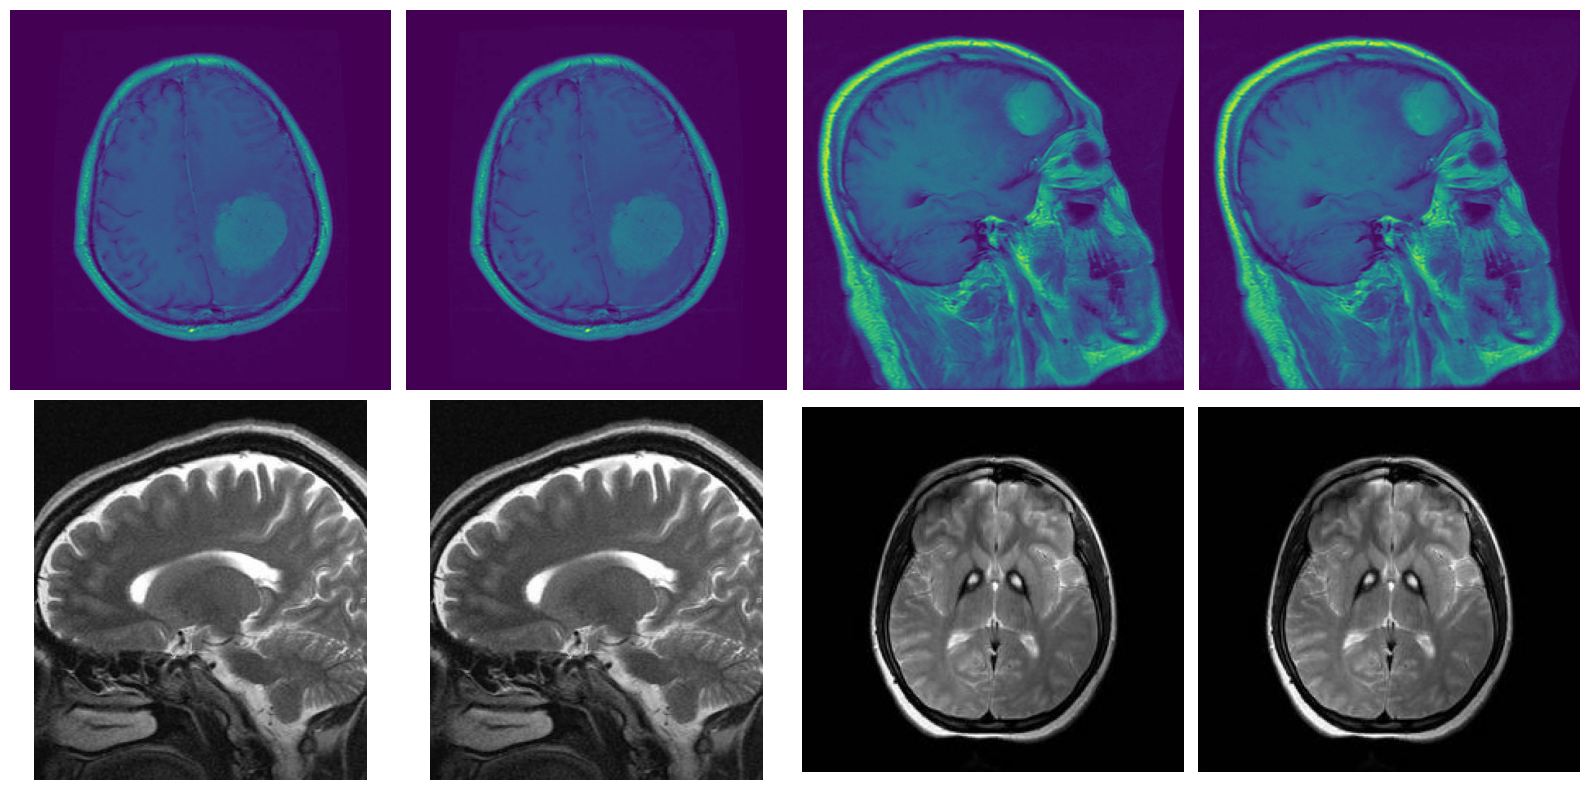

In [ ]:
# Wizualizacja przykładowych duplikatów w dataset - sprawdzenie, jak wyglądają obrazy z różnych kategorii i potencjalne duplikaty
if run_locally:
  show_images(['/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_1242.jpg', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_90.jpg', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_1274.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_98.jpg', '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_92.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_1319.jpg', '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_194.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_1004.jpg'], rows = 2, cols = 4, update_path='/Users/Marcin_Sierakowski/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2')
else:
  show_images(['/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_1242.jpg', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_90.jpg', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_1274.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_98.jpg', '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_92.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_1319.jpg', '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_194.jpg',
    '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_1004.jpg'], rows = 2, cols = 4,)


In [ ]:
# Lista ścieżek duplikatów do usunięcia
paths_to_remove = [e[0] for e in duplicates['Duplicates details']]

In [ ]:
# Usunięcie duplikatów z datasetu, pozostawiając tylko unikalne obrazy
deduplicated_ds = remove_paths_from_dataset(full_ds, paths_to_remove)

In [ ]:
# Weryfikacja oczyszczonego datasetu, czy nie zawiera już duplikatów
final_stat = find_image_duplicates(deduplicated_ds=deduplicated_ds)
final_stat

{'Number of images': 6878,
 'Number of duplicates': 0,
 'Unique images': 6878,
 'Duplicates details': []}

<span style="color: lightblue">

### 2.2. Podział datasetu na zbiory: treningowy, walidacyjny i testowy i ich przegląd

<span>

In [ ]:
# Podział datasetu na zbiory: treningowy, walidacyjny i testowy
train_ds, val_ds, test_ds = split_train_test_ds(deduplicated_ds, final_stat['Number of images'])

In [ ]:
# Podgląd datasetu treningowego (train_ds)
# Pokazuje typ i kształt danych, nie same obrazy
train_ds

<_TakeDataset element_spec=((TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(4,), dtype=tf.float32, name=None)), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [ ]:
# Podgląd datasetu walidacyjnego (val_ds)
# Pokazuje typ i kształt danych, nie same obrazy
val_ds

<_TakeDataset element_spec=((TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(4,), dtype=tf.float32, name=None)), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [ ]:
# Podgląd datasetu testowego (test_ds)
# Pokazuje typ i kształt danych, nie same obrazy
test_ds

<_SkipDataset element_spec=((TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(4,), dtype=tf.float32, name=None)), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [ ]:
# Zamiana datasetu treningowego na DataFrame dla łatwiejszej analizy
train_df = dataset_to_df(train_ds)
train_df.head(100)

,path,label
0,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
1,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
2,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3
3,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
4,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
...,...,...
95,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3
96,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,2
97,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3
98,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0


In [ ]:
# Zamiana datasetu walidacyjnego na DataFrame dla łatwiejszej analizy
val_df = dataset_to_df(val_ds)
val_df.head(100)

,path,label
0,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,2
1,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
2,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
3,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
4,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
...,...,...
95,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
96,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
97,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
98,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3


In [ ]:
# Zamiana datasetu testowego na DataFrame dla łatwiejszej analizy
test_df = dataset_to_df(test_ds)
test_df.head(100)

,path,label
0,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3
1,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,2
2,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3
3,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
4,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
...,...,...
95,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
96,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,1
97,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,0
98,/Users/Marcin_Sierakowski/.cache/kagglehub/dat...,3


<span style="color: lightblue">

### 2.3. Rozkład klas w zbiorach

<span>

In [ ]:
# Dodanie kolumny z nazwą klasy na podstawie ścieżki pliku - dla zbioru treningowego
train_df["label_name"] = train_df["path"].apply(lambda p: p.split("/")[-2])

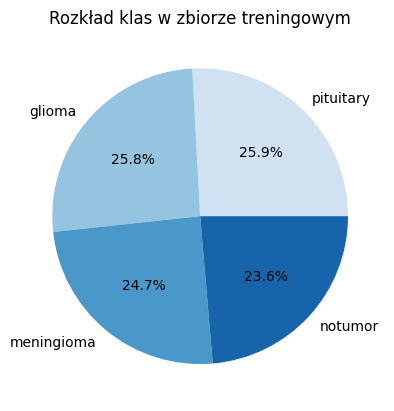

In [ ]:
# Wykres pokazujący rozkład klas w zbiorze treningowym
plot_class_distribution(train_df, "label_name", "Rozkład klas w zbiorze treningowym")

In [ ]:
# Sprawdzenie, czy klasy w zbiorze treningowym są zbalansowane
check_balance(train_df, 'label_name')

'Dane są dobrze zrównoważone.'

In [ ]:
# Dodanie kolumny z nazwą klasy na podstawie ścieżki pliku - dla zbioru walidacyjnego
val_df["label_name"] = val_df["path"].apply(lambda p: p.split("/")[-2])

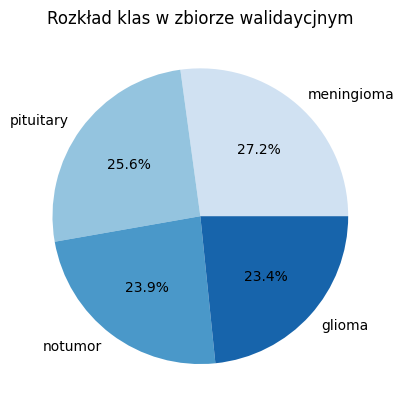

In [ ]:
# Wykres pokazujący rozkład klas w zbiorze walidacyjnym
plot_class_distribution(val_df, "label_name", "Rozkład klas w zbiorze walidaycjnym")

In [ ]:
# Sprawdzenie, czy klasy w zbiorze walidacyjnym są zbalansowane
check_balance(val_df, 'label_name')

'Dane są dobrze zrównoważone.'

In [ ]:
# Dodanie kolumny z nazwą klasy na podstawie ścieżki pliku - dla zbioru testowego
test_df["label_name"] = test_df["path"].apply(lambda p: p.split("/")[-2])

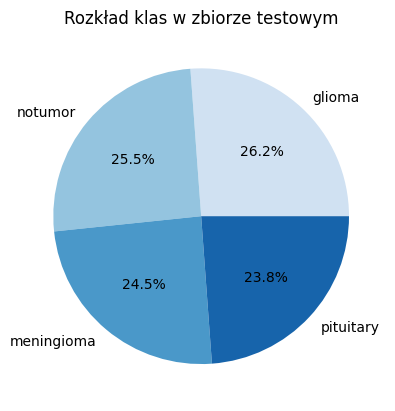

In [ ]:
# Wykres pokazujący rozkład klas w zbiorze testowym
plot_class_distribution(test_df, "label_name", "Rozkład klas w zbiorze testowym")

In [ ]:
# Sprawdzenie, czy klasy w zbiorze testowym są zbalansowane
check_balance(test_df, 'label_name')

'Dane są dobrze zrównoważone.'

**Wniosek ogólny:** Rozkład klas w zbiorze treningowym, walidacyjnym i testowym jest podobny, co wskazuje na prawidłowy podział danych. Zbiory są  zbalansowane, co sprzyja stabilnemu trenowaniu modelu klasyfikacyjnego

<span style="color: lightblue">

### 2.4. Wizualizacja zbioru i wnioski z niej płynace

<span>

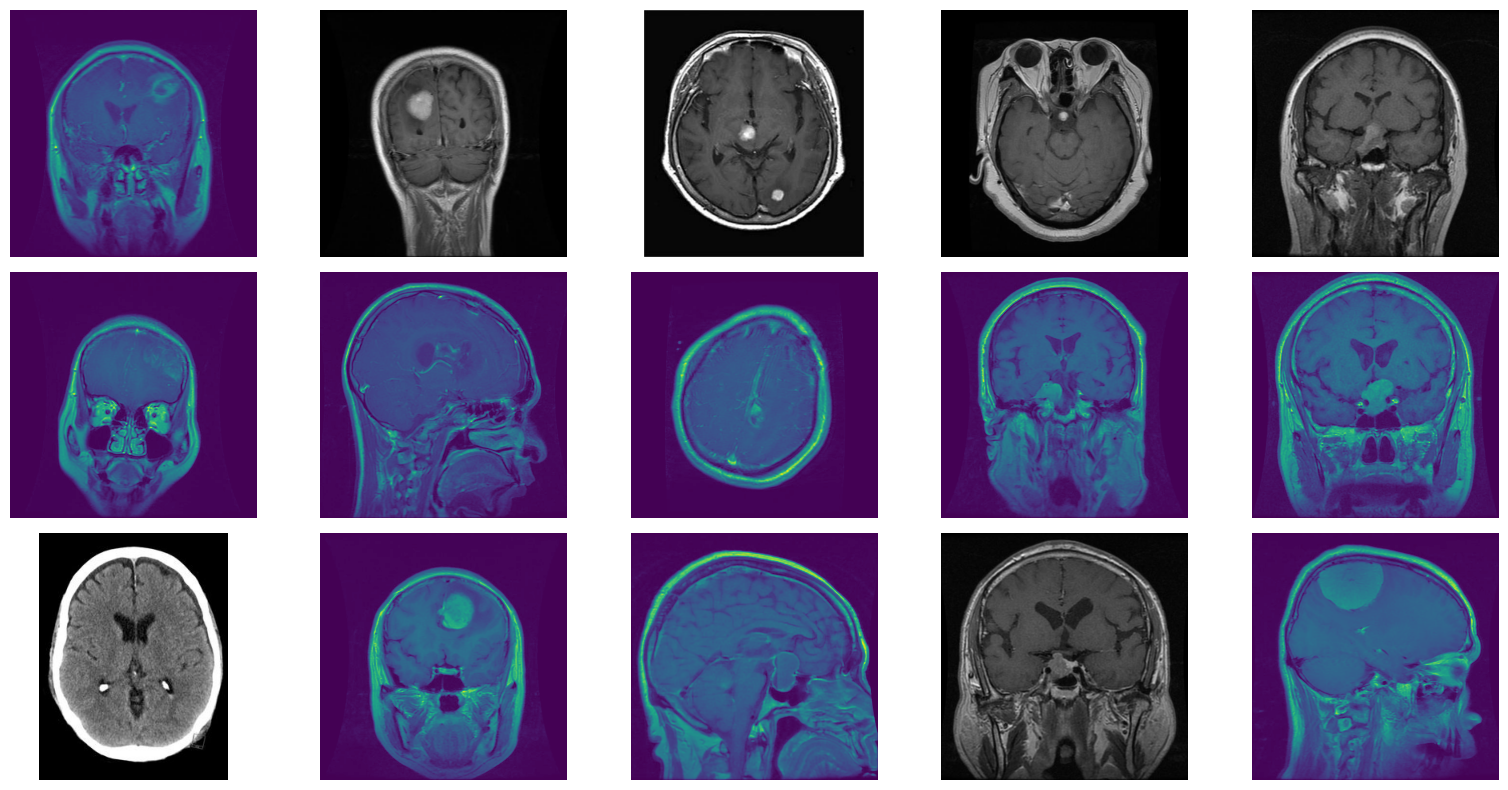

In [ ]:
# Wyświetlenie 15 losowych obrazów ze zbioru treningowego w celu wizualnej weryfikacji danych
sample = train_df.sample(n=15, random_state=42)
show_images(paths=sample["path"].tolist(), rows=3, cols=5)





**Wnioski:**

* Kolorystyka obrazów jest różna – część jest czarno-biała, część kolorowa → wymagana normalizacja.

* Jasność i kontrast są zróżnicowane → potrzebna normalizacja.

* Obrazy mają różne rozmiary → należy zastosować przycinanie (crop) lub skalowanie.

* Obrazy pochodzą z różnych płaszczyzn, mają różne orientacje i skale → przydatne będą filtry i augmentacja.

* Na obrazach widać napisy, np. pasek u góry → konieczne jest ich usunięcie lub maskowanie.

* Obrazy zawierają dużo tła → warto zastosować segmentację lub wykadrowanie obszaru zainteresowania.







<span style="color: lightblue">

### 2.5. Preprocessing obrazów

<span>

In [ ]:
# Konwersja obrazów do odcieni szarości - MRI nie wymaga informacji o kolorach
# Pomaga ujednolicić dane i zmniejszyć wpływ różnic kolorów
train_ds2 = train_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)
val_ds2 = val_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)
test_ds2 = test_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)

In [ ]:
# Centralne przycięcie obrazów do 80% rozmiaru, żeby usunąć nadmiar tła po bokach
train_ds2 = train_ds2.map(
    lambda x, y: (tf.image.central_crop(x, 0.8), y)
)
val_ds2 = val_ds2.map(
    lambda x, y: (tf.image.central_crop(x, 0.8), y)
)
test_ds2 = test_ds2.map(
    lambda x, y: (tf.image.central_crop(x, 0.8), y)
)

In [ ]:
# Zmiana rozmiaru wszystkich obrazów na 150x150 - ułatwia trenowanie i batchowanie danych
train_ds2 = train_ds2.map(
    lambda x, y: (tf.image.resize(x, (150,150)), y)
)
val_ds2 = val_ds2.map(
    lambda x, y: (tf.image.resize(x, (150,150)), y)
)
test_ds2 = test_ds2.map(
    lambda x, y: (tf.image.resize(x, (150,150)), y)
)

In [ ]:
# Normalizacja wartości pikseli do zakresu 0–1, aby przyspieszyć uczenie modelu
train_ds2 = train_ds2.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)
val_ds2 = val_ds2.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)
test_ds2 = test_ds2.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

In [ ]:
# Konwersja z powrotem do RGB (3 kanały) dla kompatybilności z pretrenowanymi modelami CNN - wracanie do RGB nie dodaje żadnej informacji, tylko powiela odcienie szarości w 3 kanałach.
train_ds2 = train_ds2.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
val_ds2 = val_ds2.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
test_ds2  = test_ds2.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))

In [ ]:
# Augmentacja zbioru treningowego: flip, rotacja, zoom
# Pomaga modelowi uczyć się bardziej uniwersalnych cech i zmniejsza overfitting
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds2 = train_ds2.map(lambda x,y: (augment(x), y))

In [ ]:
# Sprawdzenie formatu i kształtu pojedynczego elementu datasetu treningowego po preprocessingu
print(train_ds2.element_spec)

(TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(4,), dtype=tf.float32, name=None))


In [ ]:
# Kontrola datasetu: liczba obrazów w zbiorach i zakres wartości pikseli po normalizacji
# Upewnienie się, że wszystkie zbiory mają poprawną liczbę obrazów i, że normalizacja działa poprawnie (wartości pikseli powinny być w zakresie 0–1)

print("Checki:")
# Sprawdzenie rozmiarów
print(f"Train: {sum(1 for _ in train_ds2)}, Val: {sum(1 for _ in val_ds2)}, Test: {sum(1 for _ in test_ds2)}")

# Sprawdzenie zakresu pikseli
for x, y in val_ds2.take(1):
    print(f"Rozmiar pixeli w Val: {x.numpy().min():.3f} - {x.numpy().max():.3f}")


Checki:
Train: 4814, Val: 1031, Test: 1032
Rozmiar pixeli w Val: 0.000 - 0.904


<span style="color: lightblue">

## 3. Model
### 3.1. Definicja modelu CNN

<span>

In [ ]:
# 'Nasz' model CNN do klasyfikacji obrazów. Konwolucje wyciągają cechy z obrazów, a warstwy Dense klasyfikują je do jednej z 4 klas

model = model_cnn()
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Konfiguracja uczenia modelu:
# - Optymalizer Adam: szybka i stabilna aktualizacja wag
# - Funkcja straty categorical_crossentropy: odpowiednia dla klasyfikacji wieloklasowej z etykietami one-hot
# - Metryka accuracy: pozwala monitorować dokładność przewidywań podczas treningu i walidacji
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.compile(
    optimizer= tf.keras.optimizers.Adam(), #learning_rate=0.01 - rete jest parametrem optymatyzera nie compile
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Batchowanie i optymalizacja datasetu: shuffle dla treningowego, cache dla walidacyjnego/testowego, prefetch(tf.data.AUTOTUNE) dla wydajności
batched_train_ds2 = train_ds2.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)
batched_val_ds2 = val_ds2.batch(32).cache().prefetch(tf.data.AUTOTUNE)
batched_test_ds2 = test_ds2.batch(32).cache().prefetch(tf.data.AUTOTUNE)

# Shuffle na zbiorze treningowym, aby model uczył się na batchach w innej kolejności w każdej epoce
# Cache na zbiorach walidacyjnym i testowym zapisuje dane po pierwszej epoce, aby w kolejnych epokach nie powtarzać preprocessingu
# Cache nie stosujemy na zbiorze treningowym, aby augmentacja była losowa w każdej epoce
# Prefetch(tf.data.AUTOTUNE) przygotowuje następny batch w tle, podczas gdy GPU trenuje bieżący batch
# Cache i prefetch to parametry poprawiające wydajność treningu

In [ ]:
# Sprawdzenie struktury zbioru treningowego po batchowaniu i optymalizacji
batched_train_ds2

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [ ]:
# Lista callbacków: EarlyStopping przerywa trening po 5 epokach bez poprawy, ReduceLROnPlateau zmniejsza LR, gdy val_loss przestaje spadać
callbacks = [
# EarlyStopping: zatrzymuje trening po 5 epokach bez poprawy val_loss i przywraca najlepsze wagi
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    ),
# ReduceLROnPlateau: zmniejsza learning rate o połowę po 3 epokach bez poprawy val_loss, aby dokładniej dostroić wagi
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",   # obserwujemy stratę walidacyjną
        factor=0.5,           # zmniejszamy learning rate o połowę
        patience=3,           # czekamy 3 epoki bez poprawy, zanim zmniejszymy lr
        min_lr=0.000001,      # minimalna dopuszczalna wartość learning rate
        mode="min"            # szukamy minimalizacji val_loss
    )

]

<span style="color: lightblue">

### 3.2. Trenowanie modelu

<span>

In [ ]:
# Trening modelu na zbiorze treningowym z walidacją, z użyciem EarlyStopping i ReduceLROnPlateau

history = model.fit(
    batched_train_ds2,
    validation_data=batched_val_ds2,
    epochs=num_of_epochs,
    callbacks=callbacks
)

Epoch 1/30
    151/Unknown 25s 137ms/step - accuracy: 0.5785 - loss: 1.0551

2026-03-22 20:12:09.089647: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/Marcin_Sierakowski/Downloads/marcin/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


151/151 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.5787 - loss: 1.0544 - val_accuracy: 0.2599 - val_loss: 2.4663 - learning_rate: 0.0010
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.6871 - loss: 0.8102 - val_accuracy: 0.2667 - val_loss: 3.6933 - learning_rate: 0.0010
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.7167 - loss: 0.7217 - val_accuracy: 0.2658 - val_loss: 5.9729 - learning_rate: 0.0010
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.7661 - loss: 0.6381 - val_accuracy: 0.4306 - val_loss: 2.8200 - learning_rate: 0.0010
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.7788 - loss: 0.5969 - val_accuracy: 0.5490 - val_loss: 1.1719 - learning_rate: 5.0000e-04
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.8073 - loss: 0.5150 - val_accuracy: 0.7759 - val_loss: 0.5986 - learning_rate: 5.0000e-04
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.7988

<span style="color: lightblue">

### 3.3. Ocena modelu

<span>

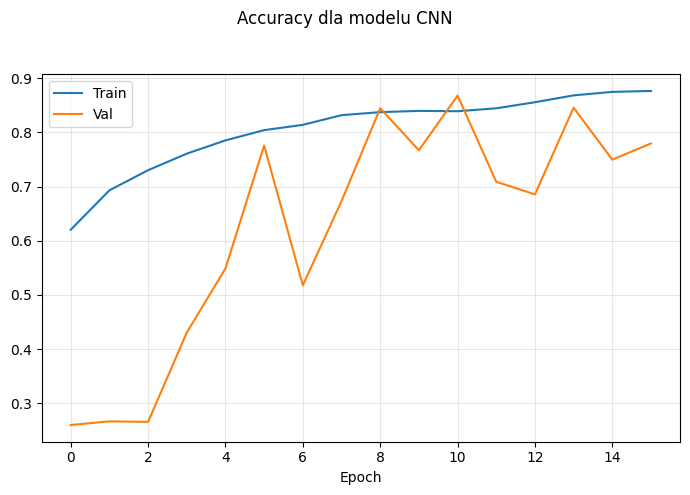

In [ ]:
# Wykres accuracy: pokazuje, jak dokładność modelu zmienia się w trakcie treningu dla treningowego i walidacyjnego

plot_accuracy(
    [history],
    [""], 'Accuracy dla modelu CNN'
)

Wnioski:

   * Accuracy na zbiorze treningowym stale rośnie i osiąga wysokie wartości, co oznacza, że model dobrze dopasowuje się do danych treningowych.
   * Accuracy na zbiorze walidacyjnym jest bardziej niestabilne, z dużymi wahaniami i ogólnie niższe niż na treningu, co wskazuje na możliwość przeuczenia (overfittingu).
   * Przebieg accuracy na walidacji jest nieregularny, co sugeruje, że model ma trudności z uogólnieniem na dane spoza treningowego zestawu.ji.


In [ ]:
# Ewaluacja modelu na zbiorze testowym: sprawdzenie dokładności i straty
loss, accuracy = model.evaluate(batched_test_ds2, verbose=0)

print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")
print(f"Strata na zbiorze testowym: {loss:.4f}")

Dokładność na zbiorze testowym: 0.8682
Strata na zbiorze testowym: 0.3648


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


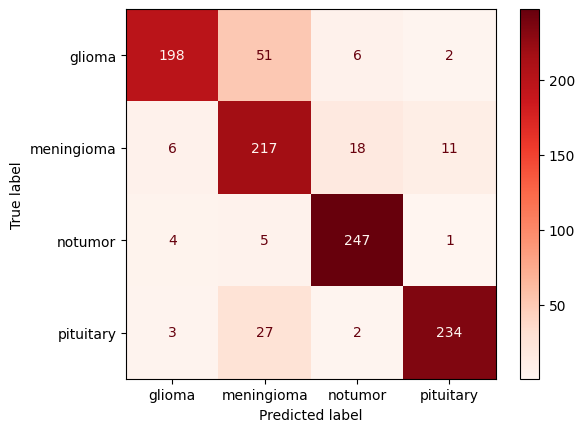

In [ ]:
# Confusion matrix - utworzenie i wyświetlenie macierzy pomyłek dla zbioru testowego, pokazuje które klasy są mylone
class_names = ["glioma", "meningioma", "notumor", "pituitary"]
y_true = np.argmax(np.concatenate([y for x, y in batched_test_ds2], axis=0), axis=1)
y_pred = np.argmax(model.predict(batched_test_ds2), axis=1)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Reds")
plt.show()

Opis:
- Glioma: 198 trafień, 51 razy pomylone jako meningioma, 6 razy jako notumor, 2 razy jako pituitary
- Meningioma: 217 trafień, 6 razy pomylone z glioma, 18 razy z notumor, 11 razy z pituitary.
- Notumor: 247 trafień, 4 razy pomylone jako glioma, 5 razy jako meningioma, 1 jako pituitary
- Pituitary: 234 trafień, 3 razy pomylone z glioma, aż 27 razy z meningioma, 2 razy z notumor

Wnioski:
* Model CNN ma trudności szczególnie z odróżnieniem klas glioma i meningioma, oraz meningioma i pituitary.
* Najmniej błędów jest w rozpoznawaniu klasy notumor.


In [ ]:
# Wyświetlenie metryk klasyfikacji (precision, recall, f1-score) dla każdej klasy na zbiorze testowym

print("Podsumowanie wyników klasyfikacji")
print(classification_report(y_true, y_pred, target_names=class_names))

Podsumowanie wyników klasyfikacji
              precision    recall  f1-score   support

      glioma       0.94      0.77      0.85       257
  meningioma       0.72      0.86      0.79       252
     notumor       0.90      0.96      0.93       257
   pituitary       0.94      0.88      0.91       266

    accuracy                           0.87      1032
   macro avg       0.88      0.87      0.87      1032
weighted avg       0.88      0.87      0.87      1032



Opis pomocniczy do czytania tabeli:
Dla każdej klasy:
- Precision (precyzja)
Pokazuje, ile z obrazów, które model zaklasyfikował jako daną klasę, faktycznie do niej należało.
Wyższa precyzja oznacza mniej fałszywych alarmów.
- Recall (czułość)
Pokazuje, ile z prawdziwych obrazów danej klasy model poprawnie wykrył.
Wyższa czułość oznacza, że model rzadziej przegapia przypadki tej klasy.
- F1-score
Pokazuje ogólną skuteczność klasyfikacji, uwzględniając zarówno precyzję, jak i czułość.
Jest to taki kompromis między tym, co model przewidział dobrze, a tym, co przegapił.
- Support
Liczba prawdziwych przypadków tej klasy w zbiorze testowym.
Pokazuje, ile było faktycznych przykładów do oceny dla danej klasy.

Podsumowanie ogólne:
 - Accuracy – ogólna dokładność modelu dla wszystkich klas.
- Macro avg – średnia skuteczność wszystkich klas, traktując każdą jednakowo.
- Weighted avg – średnia skuteczność uwzględniająca liczbę obrazów w każdej klasie.

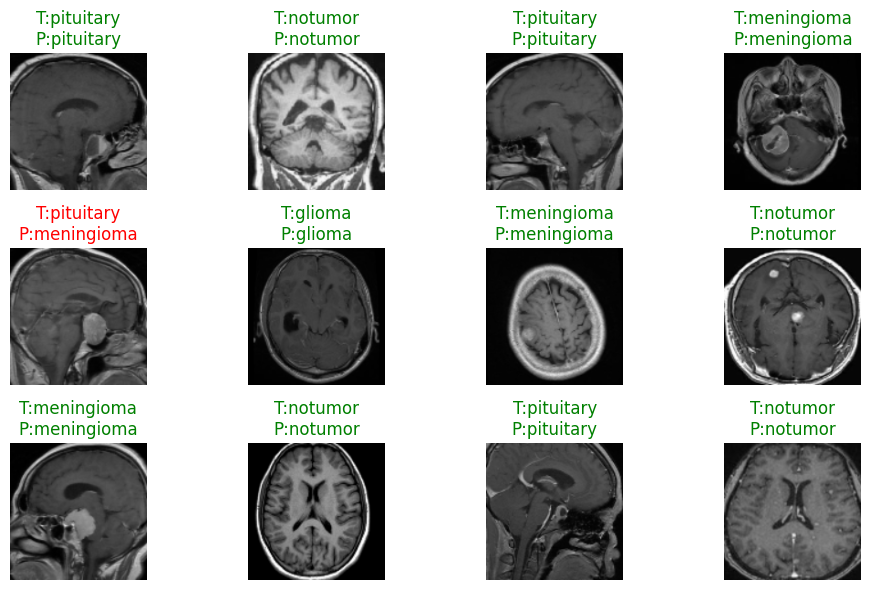

In [ ]:
# Wizualizacja 12 obrazów z testowego zbioru z prawdziwymi i przewidzianymi klasami (zielony=poprawnie, czerwony=błąd)

show_predictions(model, batched_test_ds2, tr.class_names)

<span style="color: lightblue">

### 3.4. Zapis informacji o wytrenowanym modelu

<span>

In [ ]:
# Zapis wszystkich istotnych informacji o wytrenowanym modelu CNN (dokładność, strata, prawdziwe i przewidziane etykiety, historia treningu, liczba parametrów ogółem i uczonych) do słownika, aby później móc je porównać z innymi modelami (np. EfficientNet)

cnn_results = {
    "accuracy": accuracy,
    "loss": loss,
    "y_true": y_true,
    "y_pred": y_pred,
    "history": history,
    "params": model.count_params(),
    "params_trainable": sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
}

cnn_results

{'accuracy': 0.8682170510292053,
 'loss': 0.36477676033973694,
 'y_true': array([3, 2, 3, ..., 1, 2, 2]),
 'y_pred': array([3, 2, 3, ..., 1, 2, 2]),
 'history': <keras.src.callbacks.history.History at 0x149be91f0>,
 'params': 111172,
 'params_trainable': np.int64(110724)}

<span style="color: lightblue">

### 4. Optymalizacja
### 4.1. Wybór modelu do optymalizacji

<span>

W tej sekcji przeprowadzimy optymalizację za pomocą transfer learningu z użyciem modelu Google EfficientNetB0.

Opis:
Oznacza to, że wykorzystamy model wytrenowany przez Google na zbiorze ImageNet (zawiera 1,2 miliona zdjęć w 1000 kategoriach), z którego odetniemy ostatnią warstwę (klasyfikator 1000 klas z ImageNetu). Następnie zachowamy wszystkie wagi bazowe, aby nie zostały nadpisane podczas naszego treningu. Dodamy nasz klasyfikator z nową warstwą Dense z 4 neuronami (glioma, meningioma, pituitary oraz notumor), którą jako jedyną będziemy trenować.

Celem jest porównanie naszej sieci CNN, nauczonej widzenia od zera za pomocą 3 warstw konwolucyjnych, z siecią korzystającą z wiedzy wizualnej zdobytej na milionach zdjęć.

Uzasadnienie:
Wybraliśmy EfficientNetB0, ponieważ nasz dataset zawiera około 7000 zdjęć, co jest za małą liczbą dla efektywnego trenowania większych modeli (B3/B7). B0 posiada mniejszą liczbę parametrów do nauki, dzięki czemu zmniejszamy ryzyko przeuczania się, które byłoby większe dla modeli o większej liczbie parametrów.

Dodatkowo większe modele wymagają większej pamięci, odpowiednio bardziej obciążając GPU. Dlatego, optymalizując wykorzystanie naszych zasobów, stosujemy wariant B0, bardziej odpowiadający wymaganiom naszego datasetu.

Różnica w dokładności przy wykorzystaniu większego modelu B3 dla naszego datasetu teoretycznie nie uzasadniałaby jego wykorzystania, ponieważ nasze zadanie klasyfikacji 4 klas jest znacznie prostsze niż klasyfikacja 1000 klas z ImageNet. Przy jego użyciu zwiększylibyśmy ryzyko overfittingu w sposób nieuzasadniony względem potencjalnej korzyści.

<span style="color: lightblue">

### 4.2. Preprocessing obrazów dla EfficientNetB0

<span>

Na tym etapie wykonany został osobny preprocessing, ponieważ EfficientNetB0 posiada wbudowaną normalizację.

In [ ]:
# Konwersja obrazów do odcieni szarości - MRI nie wymaga informacji o kolorach -  - jak dla modelu CNN
# Pomaga ujednolicić dane i zmniejszyć wpływ różnic kolorów

train_ds_effNet = train_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)
val_ds_effNet = val_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)
test_ds_effNet = test_ds.map(
    lambda data, path: (tf.image.rgb_to_grayscale(data[0]), data[1])
)

In [ ]:
# Centralne przycięcie obrazów do 80% rozmiaru, żeby usunąć nadmiar tła po bokach - jak dla modelu CNN

train_ds_effNet = train_ds_effNet.map(lambda data, path: (tf.image.central_crop(data[0], 0.8), data[1]))
val_ds_effNet = val_ds_effNet .map(lambda data, path: (tf.image.central_crop(data[0], 0.8), data[1]))
test_ds_effNet = test_ds_effNet.map(lambda data, path: (tf.image.central_crop(data[0], 0.8), data[1]))

In [ ]:
# Zmiana rozmiaru wszystkich obrazów na 150x150 - ułatwia trenowanie i batchowanie danych - jak dla modelu CNN

train_ds_effNet = train_ds_effNet.map(lambda x, y: (tf.image.resize(x, (150,150)),y))
val_ds_effNet = val_ds_effNet.map(lambda x, y: (tf.image.resize(x, (150,150)),y))
test_ds_effNet = test_ds_effNet.map(lambda x, y: (tf.image.resize(x, (150,150)),y))

In [ ]:
# Konwersja z powrotem do RGB (3 kanały) dla kompatybilności z pretrenowanymi modelami CNN - wracanie do RGB nie dodaje żadnej informacji, tylko powiela odcienie szarości w 3 kanałach - jak dla modelu CNN
train_ds_effNet = train_ds_effNet.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
val_ds_effNet = val_ds_effNet.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
test_ds_effNet = test_ds_effNet.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))

In [ ]:
# Augmentacja zbioru treningowego: flip, rotacja, zoom - jak dla modelu CNN
# Pomaga modelowi uczyć się bardziej uniwersalnych cech i zmniejsza overfitting

augment_effNet = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

train_ds_effNet = train_ds_effNet.map(lambda x, y: (augment_effNet(x), y))

In [ ]:
# Batchowanie i optymalizacja datasetu: shuffle dla treningowego, cache dla walidacyjnego/testowego, prefetch(tf.data.AUTOTUNE) dla wydajności - jak dla modelu CNN

batched_train_ds_effNet = train_ds_effNet.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)
batched_val_ds_effNet = val_ds_effNet.batch(32).cache().prefetch(tf.data.AUTOTUNE)
batched_test_ds_effNet = test_ds_effNet.batch(32).cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
# Kontrola datasetu: liczba obrazów w zbiorach i zakres wartości pikseli
# Upewnienie się, że wszystkie zbiory mają poprawną liczbę obrazów oraz że wartośċ pikseli to 0-255 zamiast 0-1

for x, y in batched_val_ds_effNet.take(1):
  print(f"Zakres piksel w val dla EffcientNet: {x.numpy().min():.1f} - {x.numpy().max():.1f}")

Zakres piksel w val dla EffcientNet: 0.0 - 255.0


2026-03-22 20:18:22.726529: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


<span style="color: lightblue">

### 4.3. Definicja modelu EfficientNet z wykokrzystaniem transfer learningu

<span>

In [ ]:
# Model oparty na architekturze EfficientNetB0 z wykorzystaniem transfer learningu

model_effNet = effNet_model()
model_effNet.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 150, 150,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 150, 150,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 150, 150,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 151, 151,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 75, 75,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 75, 75,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 75, 75,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 75, 75,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 75, 75,    │        512 │ block1a_se_excit

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Konfiguracja uczenia modelu:
# - Optymalizer Adam: szybka i stabilna aktualizacja wag
# - Funkcja straty categorical_crossentropy: odpowiednia dla klasyfikacji wieloklasowej z etykietami one-hot
# - Metryka accuracy: pozwala monitorować dokładność przewidywań podczas treningu i walidacji

model_effNet.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

<span style="color: lightblue">

### 4.4. Trenowanie modelu EfficientNet z wykorzystaniem transfer learningu

<span>

In [ ]:
# Trening modelu na zbiorze treningowym z walidacją, z użyciem EarlyStopping i ReduceLROnPlateau

history_effNet = model_effNet.fit(
    batched_train_ds_effNet,
    validation_data=batched_val_ds_effNet,
    epochs=num_of_epochs,
    callbacks=callbacks
)

Epoch 1/30
    151/Unknown 18s 70ms/step - accuracy: 0.5714 - loss: 0.9753

/Users/Marcin_Sierakowski/Downloads/marcin/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


151/151 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.5723 - loss: 0.9738 - val_accuracy: 0.8312 - val_loss: 0.4715 - learning_rate: 0.0010
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.8141 - loss: 0.5190 - val_accuracy: 0.8681 - val_loss: 0.3851 - learning_rate: 0.0010
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.8343 - loss: 0.4449 - val_accuracy: 0.8652 - val_loss: 0.3646 - learning_rate: 0.0010
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8399 - loss: 0.4278 - val_accuracy: 0.8700 - val_loss: 0.3585 - learning_rate: 0.0010
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.8644 - loss: 0.3894 - val_accuracy: 0.8749 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8483 - loss: 0.3971 - val_accuracy: 0.8817 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8552 - loss: 0.3787

<span style="color: lightblue">

### 4.4. Ocena modelu EfficientNet
<span>


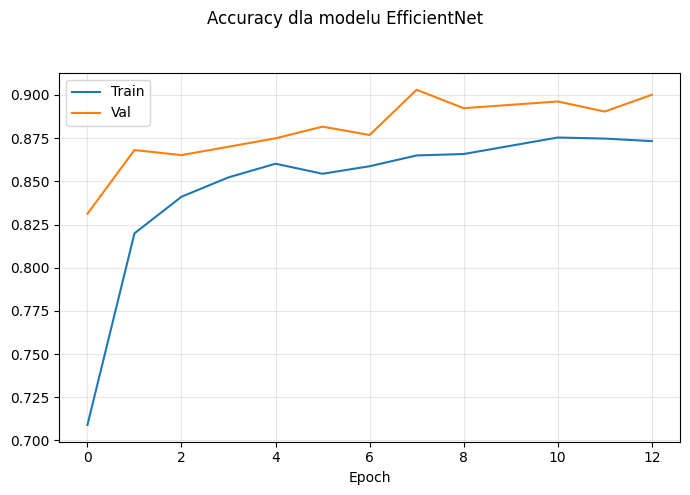

In [ ]:
# Wykres accuracy: pokazuje, jak dokładność modelu zmienia się w trakcie treningu dla treningowego i walidacyjnego
plot_accuracy(
    [history_effNet],
    [""], 'Accuracy dla modelu EfficientNet'
)

Wnioski:
   * Accuracy na zbiorze treningowym również rośnie, ale z mniejszą dynamiką i osiąga stabilne, wysokie wartości.
   * Accuracy na zbiorze walidacyjnym jest nie tylko stabilne, ale często wyższe niż na treningu, co może świadczyć o dobrym uogólnieniu i działaniu transfer learningu oraz technik regularyzacji.
   * Mniejsza różnica między accuracy treningowym a walidacyjnym wskazuje na lepszą zdolność generalizacji modelu EfficientNet.



In [ ]:
# Ewaluacja modelu na zbiorze testowym: sprawdzenie dokładności i straty

loss_effNet, accuracy_effNet = model_effNet.evaluate(batched_test_ds_effNet, verbose=0)
print(f"EfficientNetB0 - Dokłądność na zbiorze testowym: {accuracy_effNet:.4f}")
print(f"EfficientNetB0 - Strata na zbiorze testowym: {loss_effNet:.4f}")


EfficientNetB0 - Dokłądność na zbiorze testowym: 0.8934
EfficientNetB0 - Strata na zbiorze testowym: 0.2951


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step


2026-03-22 20:21:52.879933: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


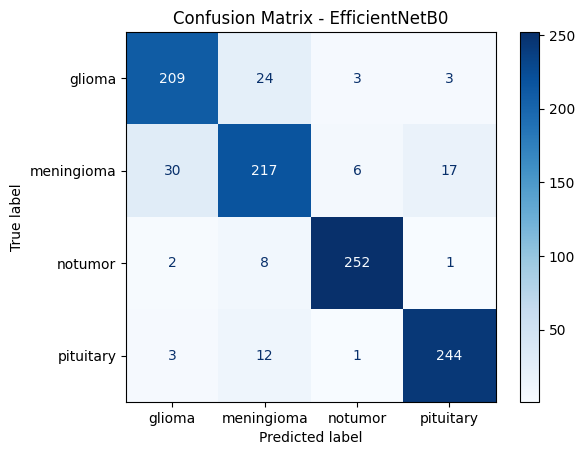

In [ ]:
# Confusion matrix - utworzenie i wyświetlenie macierzy pomyłek dla zbioru testowego, pokazuje które klasy są mylone

class_names = tr.class_names

y_true_effNet = np.argmax(np.concatenate([y for xx, y in batched_test_ds_effNet], axis=0), axis=1)
y_pred_effNet = np.argmax(model_effNet.predict(batched_test_ds_effNet), axis=1)

cm_effNet = confusion_matrix(y_true_effNet, y_pred_effNet)
ConfusionMatrixDisplay(cm_effNet, display_labels=class_names).plot(cmap="Blues")
plt.title("Confusion Matrix - EfficientNetB0")
plt.show()


Opis:
- Glioma: 209 trafień, 24 razy pomylone jako meningioma, 3 razy jako notumor, 3 razy jako pituitary
- Meningioma: 217 trafień, 30 razy pomylone jako glioma, 6 razy jako notumor, 17 razy jako pituitary.
- Notumor: 252 trafień, 2 razy pomylone jako glioma, 8 razy jako meningioma, 1 raz jako pituitary.
- Pituitary: 244 trafień, 3 razy pomylone jako glioma, 12 razy jako meningioma, 1 raz jako notumor.

Wnioski:
* Model ma wyraźne trudności z rozróżnieniem klas glioma i meningioma
* Występuje również sporo pomyłek między pituitary a meningioma, co wskazuje na podobieństwo cech tych guzów w oczach modelu.
* Najlepiej rozpoznawaną klasą jest notumor, z bardzo niską liczbą błędów.


In [ ]:
# Wyświetlenie metryk klasyfikacji (precision, recall, f1-score) dla każdej klasy na zbiorze testowym

print("Podsumowanie wyników klasyfikacji po transfer learningu")
print(classification_report(y_true_effNet, y_pred_effNet, target_names=class_names))

Podsumowanie wyników klasyfikacji po transfer learningu
              precision    recall  f1-score   support

      glioma       0.86      0.87      0.87       239
  meningioma       0.83      0.80      0.82       270
     notumor       0.96      0.96      0.96       263
   pituitary       0.92      0.94      0.93       260

    accuracy                           0.89      1032
   macro avg       0.89      0.89      0.89      1032
weighted avg       0.89      0.89      0.89      1032



Opis pomocniczy do czytania tabeli:

Dla każdej klasy:
- Precision (precyzja)
Pokazuje, ile z obrazów, które model zaklasyfikował jako daną klasę, faktycznie do niej należało.
Wyższa precyzja oznacza mniej fałszywych alarmów.
- Recall (czułość)
Pokazuje, ile z prawdziwych obrazów danej klasy model poprawnie wykrył.
Wyższa czułość oznacza, że model rzadziej przegapia przypadki tej klasy.
- F1-score
Pokazuje ogólną skuteczność klasyfikacji, uwzględniając zarówno precyzję, jak i czułość.
Jest to taki kompromis między tym, co model przewidział dobrze, a tym, co przegapił.
- Support
Liczba prawdziwych przypadków tej klasy w zbiorze testowym.
Pokazuje, ile było faktycznych przykładów do oceny dla danej klasy.

Podsumowanie ogólne:
 - Accuracy – ogólna dokładność modelu dla wszystkich klas.
- Macro avg – średnia skuteczność wszystkich klas, traktując każdą jednakowo.
- Weighted avg – średnia skuteczność uwzględniająca liczbę obrazów w każdej klasie.

<span style="color: lightblue">

### 4.5. Zapis informacji o wytrenowanym modelu EfficientNet

<span>

In [ ]:
# Zapis wszystkich istotnych informacji o wytrenowanym modelu EfficientNet (dokładność, strata, prawdziwe i przewidziane etykiety, historia treningu, liczba parametrów ogółem i uczonych) do słownika, aby później móc je porównać z innymi modelami (np. EfficientNet)

effNet_results = {
    "accuracy": accuracy_effNet,
    "loss": loss_effNet,
    "y_true": y_true_effNet,
    "y_pred": y_pred_effNet,
    "history": history_effNet,
    "params": model_effNet.count_params(),
    "params_trainable": sum([tf.keras.backend.count_params(i) for i in model_effNet.trainable_weights])
}

effNet_results

{'accuracy': 0.893410861492157,
 'loss': 0.29511117935180664,
 'y_true': array([0, 3, 1, ..., 0, 3, 1]),
 'y_pred': array([0, 3, 3, ..., 0, 3, 1]),
 'history': <keras.src.callbacks.history.History at 0x1514b5b50>,
 'params': 4054695,
 'params_trainable': np.int64(5124)}

<span style="color: lightblue">

## 5. Wnioski
### 5.1.  Porównanie wyników - nasz model CNN vs model EfficientNet

<span>





In [ ]:
# Wygenerowanie tabeli w markdown - porównanie modeli CNN i EfficientNet

print(generate_markdown_table(cnn_results, effNet_results))

| Metryka                        | CNN     | EfficientNetB0   |
|:-------------------------------|:--------|:-----------------|
| Test Accuracy                  | 86.82%  | 89.34%           |
| Test Loss                      | 0.3648  | 0.2951           |
| Macro F1-Score                 | 86.87%  | 89.31%           |
| Liczba parametrów ogółem       | 111,172 | 4,054,695        |
| Liczba parametrów trenowalnych | 110,724 | 5,124            |
| Epoki do zatrzymania           | 16      | 13               |


| Metryka                        | CNN     | EfficientNetB0   |
|:-------------------------------|:--------|:-----------------|
| Test Accuracy                  | 86.82%  | 89.34%           |
| Test Loss                      | 0.3648  | 0.2951           |
| Macro F1-Score                 | 86.87%  | 89.31%           |
| Liczba parametrów ogółem       | 111,172 | 4,054,695        |
| Liczba parametrów trenowalnych | 110,724 | 5,124            |
| Epoki do zatrzymania           | 16      | 13               |

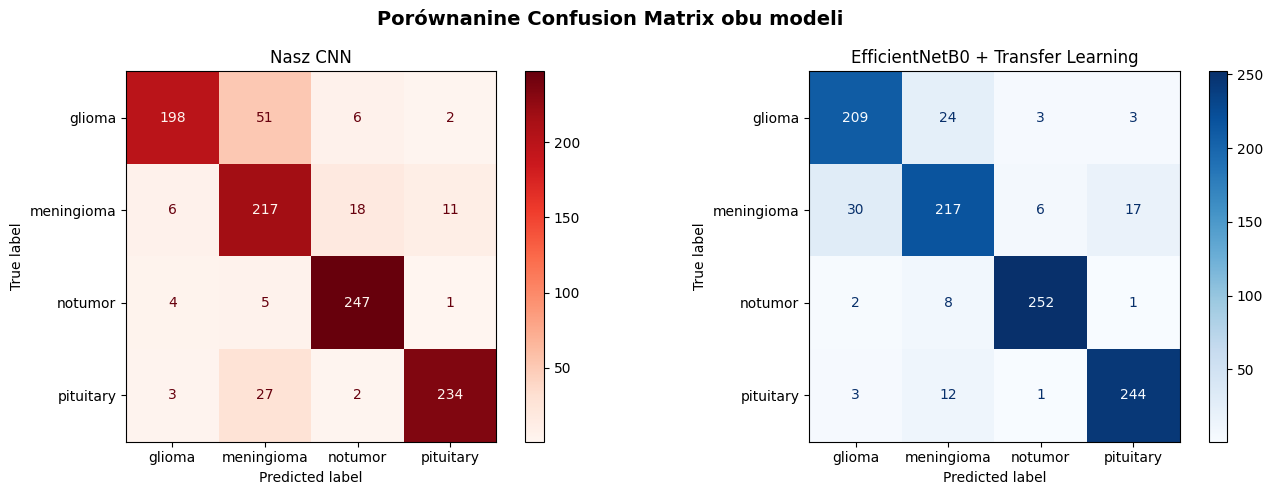

In [ ]:
# Porównanie confusion matrix dla CNN i EfficientNet
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

ConfusionMatrixDisplay(confusion_matrix(cnn_results["y_true"], cnn_results["y_pred"]), display_labels=class_names).plot(cmap="Reds", ax=ax1)
ax1.set_title("Nasz CNN")

ConfusionMatrixDisplay(confusion_matrix(effNet_results["y_true"],effNet_results["y_pred"]),
display_labels=class_names).plot(cmap="Blues", ax=ax2)
ax2.set_title("EfficientNetB0 + Transfer Learning")

plt.suptitle("Porównanine Confusion Matrix obu modeli", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Wnioski:

Glioma:
CNN: 198 poprawnych klasyfikacji, 51 pomyłek jako meningioma.
EfficientNet: 209 poprawnych, mniej błędów (24) w klasyfikacji na meningioma.
Wniosek: EfficientNet lepiej rozpoznaje gliomę, popełniając mniej błędów.

Meningioma:
CNN: 217 poprawnych, ale 18 pomyłek jako notumor i 11 jako pituitary.
EfficientNet: również 217 poprawnych, ale mniej błędów jako notumor (6) i pituitary (17), za to więcej błędów jako glioma (30).
Wniosek: Oba modele dobrze radzą sobie z meningiomą, ale CNN ma więcej pomyłek rozproszonych na różne klasy, a EfficientNet popełnia nieco więcej błędów jako glioma.

Notumor (brak guza):
CNN: 247 poprawnych, bardzo mało błędów.
EfficientNet: 252 poprawne, jeszcze mniej błędów.
Wniosek: Oba modele bardzo dobrze rozpoznają brak guza, EfficientNet jest tu minimalnie lepszy.

Pituitary:
CNN: 234 poprawnych, 27 błędów jako meningioma.
EfficientNet: 244 poprawnych, tylko 12 błędów jako meningioma.
Wniosek: EfficientNet radzi sobie znacznie lepiej z klasyfikacją pituitary, znacznie mniej pomyłek.


* EfficientNet ma mniej błędów FN i FP dla glioma i pituitary — czyli lepiej wykrywa te klasy i rzadziej myli inne klasy z nimi.
* CNN ma większą liczbę błędów w wykrywaniu glioma i pituitary (więcej FN).
* Dla meningiomy EfficientNet ma mniej FP, ale więcej FN, co sugeruje, że czasem „przegapia” tę klasę.
* Oba modele bardzo dobrze rozpoznają brak guza, z lekką przewagą EfficientNet.

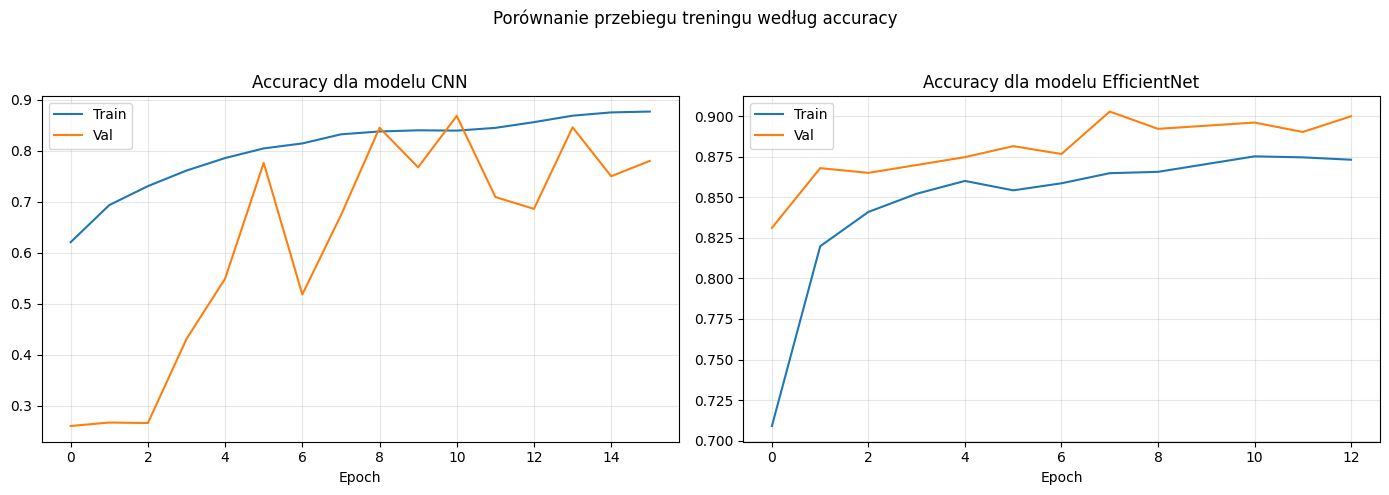

In [ ]:
# Porównanie accuracy dla CNN i EfficientNet

plot_accuracy(
    [history, history_effNet],
    ["Accuracy dla modelu CNN", "Accuracy dla modelu EfficientNet"], 'Porównanie przebiegu treningu według accuracy'
)

Wnioski:

Jak można zaobserwować na powyższych wykresach, w przypadku modelu CNN wartości accuracy są wyższe dla zbioru treningowego niż walidacyjnego (train > val). Natomiast dla modelu opartego o EfficientNet obserwujemy odwrotną zależność — wyższe accuracy występuje dla zbioru walidacyjnego (val > train).

Zjawisko to wynika z różnic w stopniu przeuczenia oraz wpływie technik regularyzacji. W modelu CNN dominuje przeuczenie (overfitting), co powoduje lepsze dopasowanie do danych treningowych kosztem gorszej generalizacji. Z kolei w modelu EfficientNet, wykorzystującym transfer learning, efekt przeuczenia jest znacznie ograniczony, a większą rolę odgrywa tzw. „handicap treningowy”, wynikający z zastosowania dropout oraz augmentacji danych.

Oba modele podlegają jednocześnie wpływowi tych czynników, jednak kluczowa jest proporcja liczby parametrów trenowalnych do rozmiaru zbioru treningowego. Model CNN posiada około 110 724 parametrów trenowalnych przy zbiorze liczącym około 4900 obrazów, co sprzyja przeuczeniu. Natomiast model EfficientNet (z zamrożoną bazą) ma jedynie około 5 124 parametrów trenowalnych przy tej samej liczbie danych, dzięki czemu ryzyko przeuczenia jest minimalne, a dominującym efektem staje się regularyzacja.

W rezultacie model EfficientNet wykazuje lepszą zdolność uogólniania, co znajduje odzwierciedlenie w wyższych wynikach na zbiorze walidacyjnym.


Takie obserwacje potwierdzają, że wykorzystanie EfficientNet z transfer learningiem jest korzystne dla uzyskania bardziej wiarygodnych i uogólnialnych wyników w klasyfikacji obrazów MRI guzów mózgu.



<span style="color: lightblue">

### 5.2.  Analiza błędów

<span>


Dokonywana jest analiza obrazów, na których modele popełniły błędy. Celem jest identyfikacja wzorców występujących w niepoprawnych predykcjach oraz weryfikacja, czy model oparty na EfficientNet unika błędów charakterystycznych dla modelu CNN.


In [ ]:
#Analiza błędów

errors_cnn = collect_errors(model, batched_test_ds2)
errors_effNet = collect_errors(model_effNet, batched_test_ds_effNet, normalize=True)

print(f"Liczba błędów CNN wynosi {len(errors_cnn)}.")
print(f"Liczba błędów EfficientNet wynosi {len(errors_effNet)}.")

Liczba błędów CNN wynosi 136.
Liczba błędów EfficientNet wynosi 110.


In [ ]:
#Wyprintowanie errorów:
print_top_errors(errors_cnn, class_names, "CNN")
print_top_errors(errors_effNet, class_names, "EfficientNet + Transfer Learning")


===== Najczęstsze pomyłki modelu CNN =====

Format: Prawda → Predykcja

1. glioma → meningioma: 51 przypadków
2. pituitary → meningioma: 27 przypadków
3. meningioma → notumor: 18 przypadków
4. meningioma → pituitary: 11 przypadków
5. meningioma → glioma: 6 przypadków



===== Najczęstsze pomyłki modelu EfficientNet + Transfer Learning =====

Format: Prawda → Predykcja

1. meningioma → glioma: 30 przypadków
2. glioma → meningioma: 24 przypadków
3. meningioma → pituitary: 17 przypadków
4. pituitary → meningioma: 12 przypadków
5. notumor → meningioma: 8 przypadków




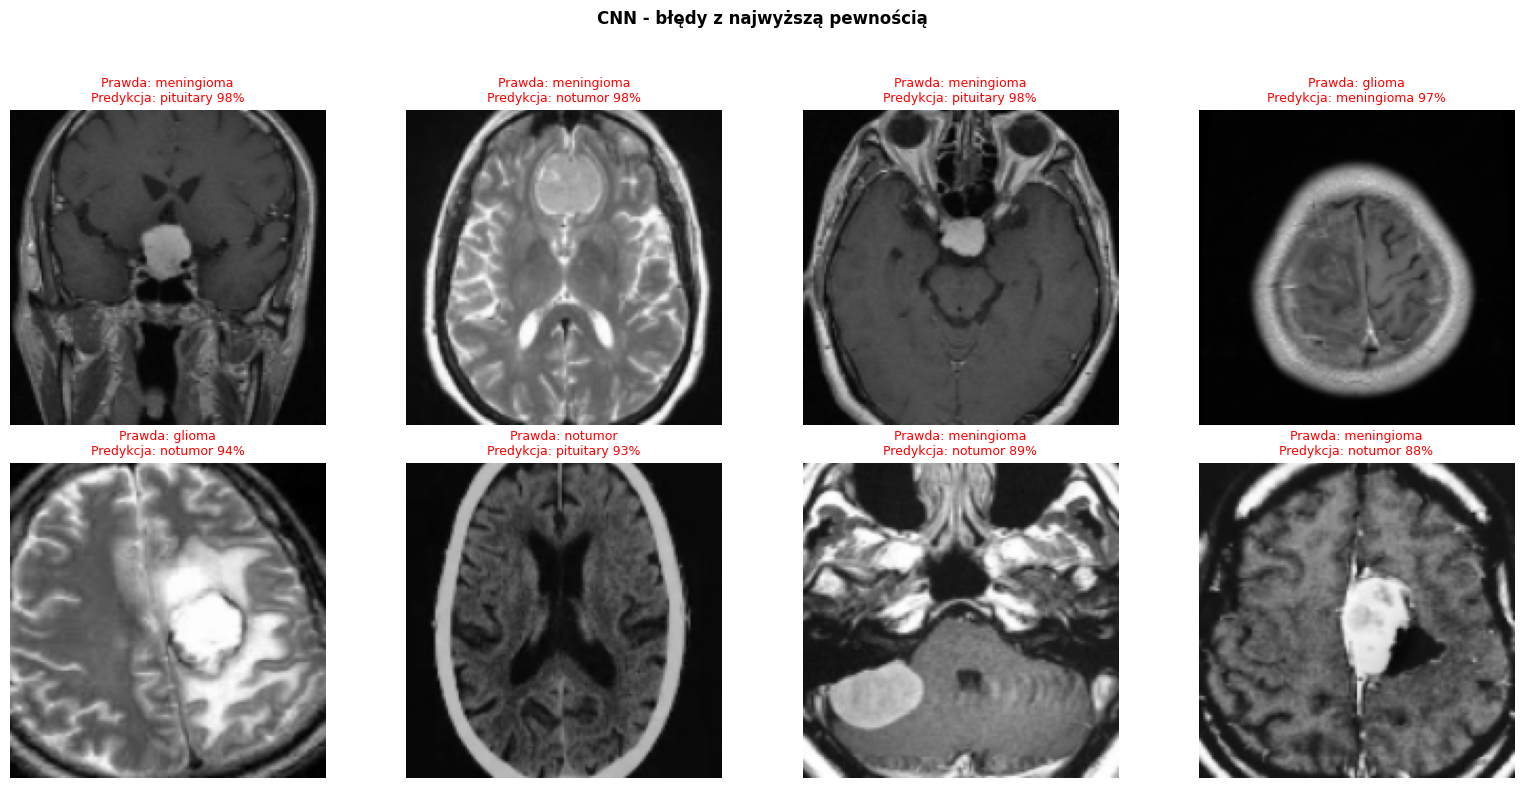

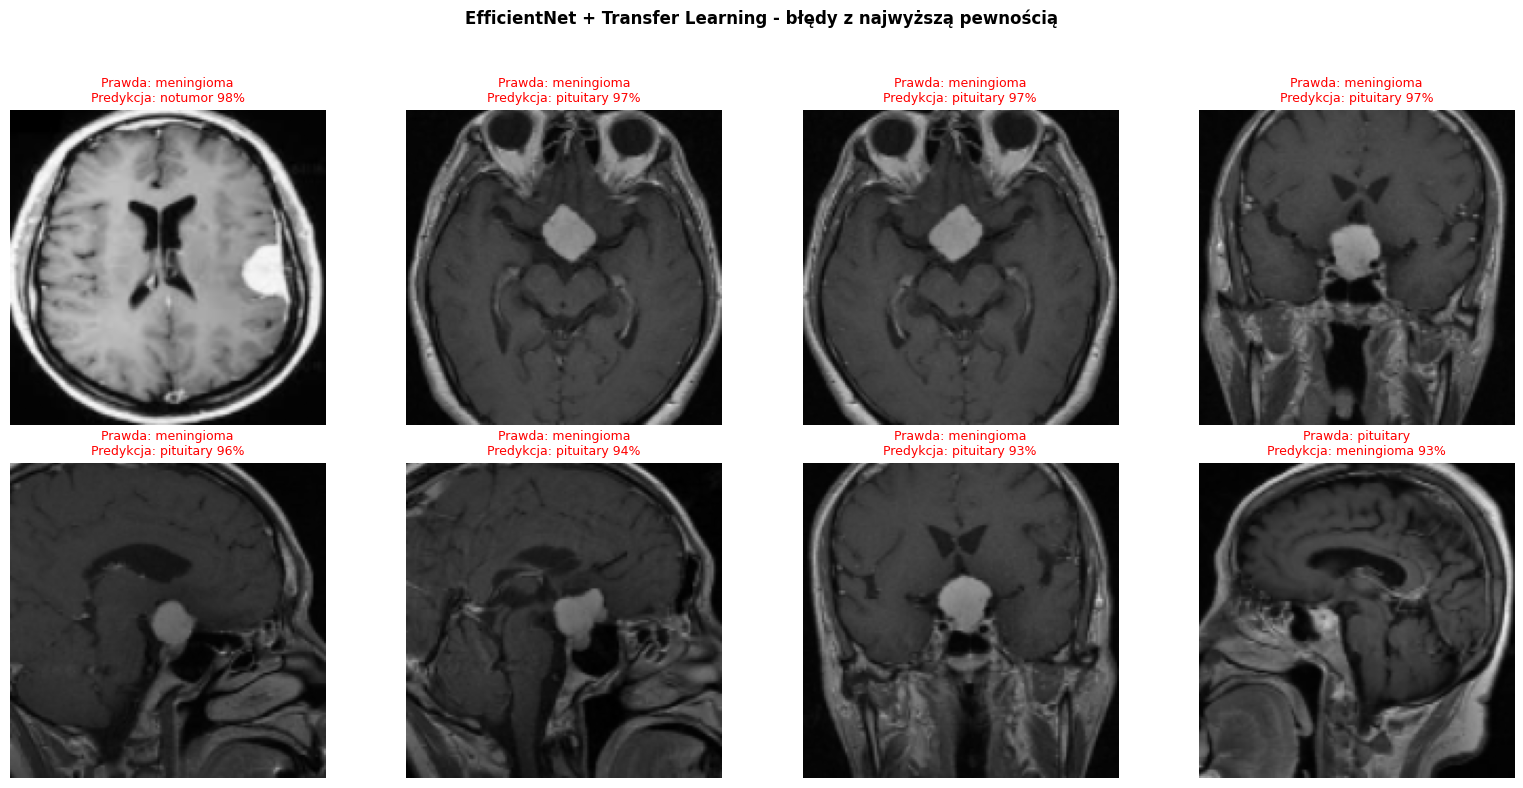

In [ ]:
# Wyświetlenie obrazów z błędnymi predykcjami o najwyższej pewności dla obydwu modeli:

# CNN
plot_top_errors(errors_cnn, class_names, model_name="CNN", n_show=8)

# EfficientNet
plot_top_errors(errors_effNet, class_names, model_name="EfficientNet + Transfer Learning", n_show=8)

<span style="color: lightblue">

### 5.3. Wizualizacja obszarów kluczowych dla decyzji o klasyfikacji

<span>


Grad-CAM (Gradient-weighted Class Activation Mapping) to metoda wizualizacji, która pozwala określić, które obszary obrazu miały największy wpływ na decyzję modelu klasyfikacyjnego. Generuje ona mapę aktywacji, wskazującą regiony istotne z punktu widzenia predykcji danej klasy.

Metoda ta została wybrana, ponieważ w analizie obrazów MRI guzów mózgu istotna jest nie tylko skuteczność klasyfikacji, ale również interpretowalność modelu. Grad-CAM umożliwia weryfikację, czy model opiera swoje decyzje na obszarach odpowiadających rzeczywistym zmianom nowotworowym. Dzięki temu stanowi narzędzie wspierające ocenę poprawności działania modelu oraz zwiększa wiarygodność uzyskanych wyników.


In [ ]:

#Funkcja Grad-cam do generowania heatmaapy

def make_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.Model(
        inputs = model.input,
        outputs = [
            model.get_layer(last_conv_layer_name).output, #mapa ficzerów
            model.output # predykcje
        ]
    )
# Przepuszczamy obraz przez model do zarejestrowania ścieżki obliczceń, aby następnie obliczyyć gradienty
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

#obliczamy gradientt
    grads = tape.gradient(class_score, conv_outputs)
# Uśredniamy gradient z każdej mapy robimy jedną liczbę
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

# Mnożymy ficzer mapy przzez ichh wagi i sumujemy
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

#Normalizacja
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) > 0:
      heatmap = heatmap / tf.reduce_max(heatmap) # Skkalujemy do 0-1

    return(
        heatmap.numpy(),
        int(predicted_class.numpy()),
        float(predictions[0][predicted_class].numpy())
    )

In [ ]:
# funkcja wwyświetlania wyników
def  show_gradcam(image, heatmap, true_class, pred_class, confidance, class_names):
  fig, axes = plt.subplots(1,3, figsize=(14,4))

#orginalny obraz
  axes[0].imshow(image)
  axes[0].set_title(f"Oryginał Prawda {class_names[true_class]}", fontsize=10)
  axes[0].axis("off")

# heatmap grad-CAM
  heatmap_resized = tf.image.resize(
      heatmap[..., np.newaxis],
      (image.shape[0], image.shape[1])
  ).numpy().squeeze()

  axes[1].imshow(heatmap_resized, cmap="jet")
  axes[1].set_title("Heatmapa Grad-CAM")
  axes[1].axis("off")

# Heatmapa założna na obraz
  axes[2].imshow(image)
  axes[2].imshow(heatmap_resized, cmap="jet", alpha=0.4)
  is_correct = true_class == pred_class
  axes[2].set_title(
      f"Predykcja: {class_names[pred_class]} ({confidence:.0%})",
      color="green" if is_correct else "red", fontsize=10
  )
  axes[2].axis("off")

  plt.tight_layout()
  plt.show()


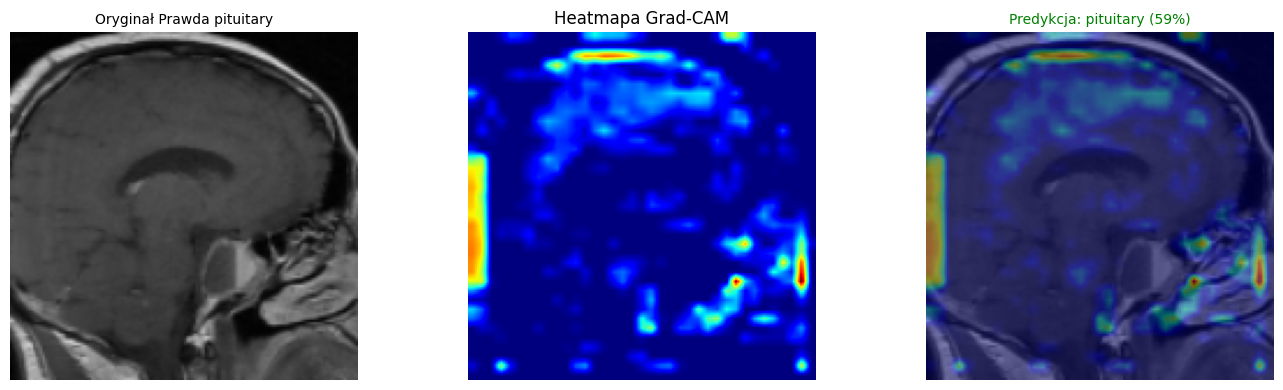

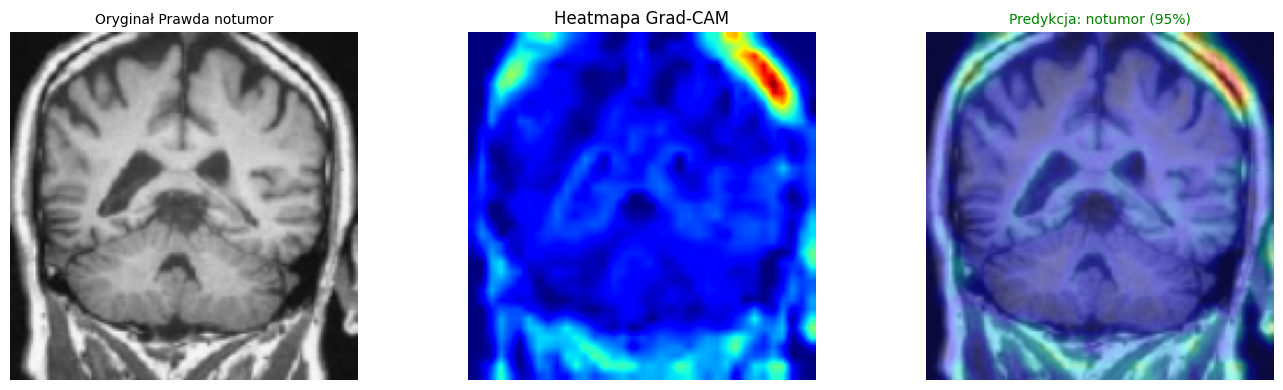

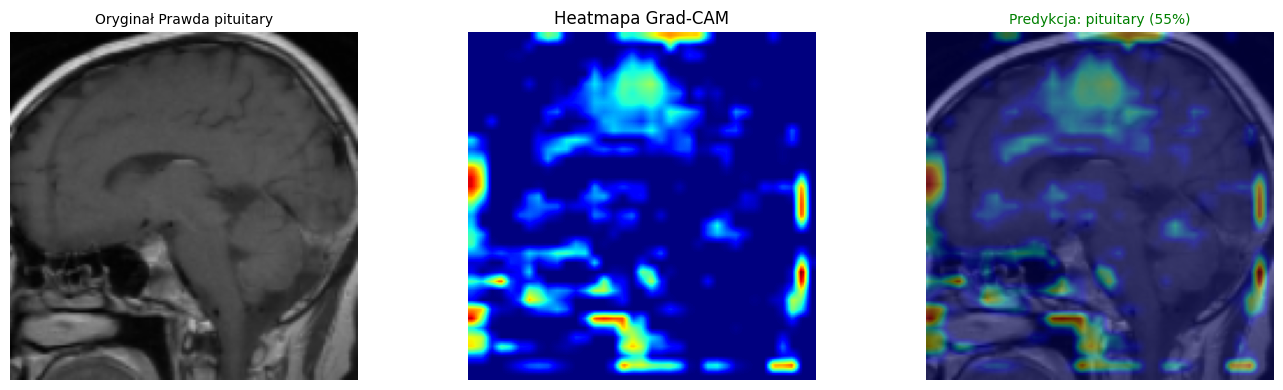

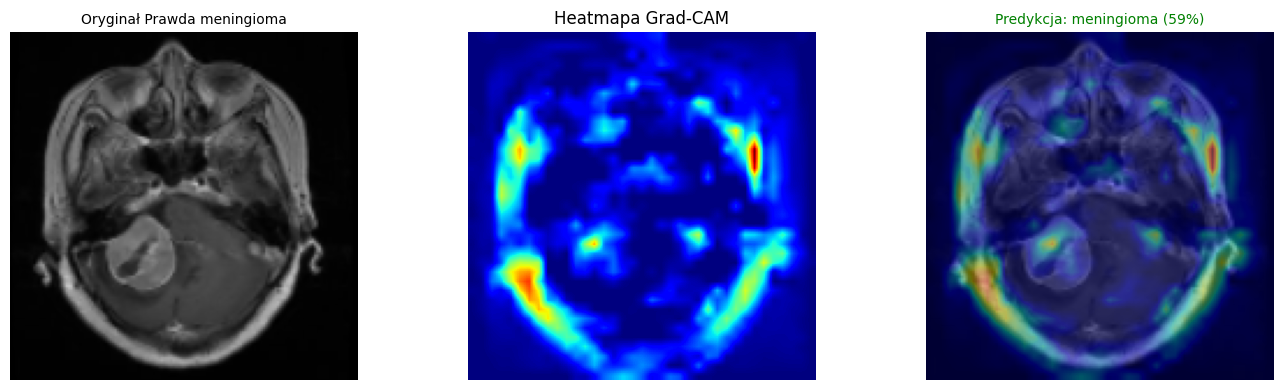

In [ ]:
# Grad-CAM dla modelu CNN

last_conv_name_cnn = None
for layer in model.layers:
  if isinstance(layer, layers.Conv2D):
    last_conv_name_cnn = layer.name

sample_batch_x, sample_batch_y = next(iter(batched_test_ds2)) #obrazy do wizulazacji

for i in range(4):
  img = sample_batch_x[i]
  true_class = int(np.argmax(sample_batch_y[i].numpy()))

  img_batch = tf.expand_dims(img, axis=0) # batch dla finkcji

  heatmap, pred_class, confidence = make_gradcam_heatmap(
      model, img_batch, last_conv_name_cnn
  )

  show_gradcam(img.numpy(), heatmap, true_class, pred_class, confidence, class_names)

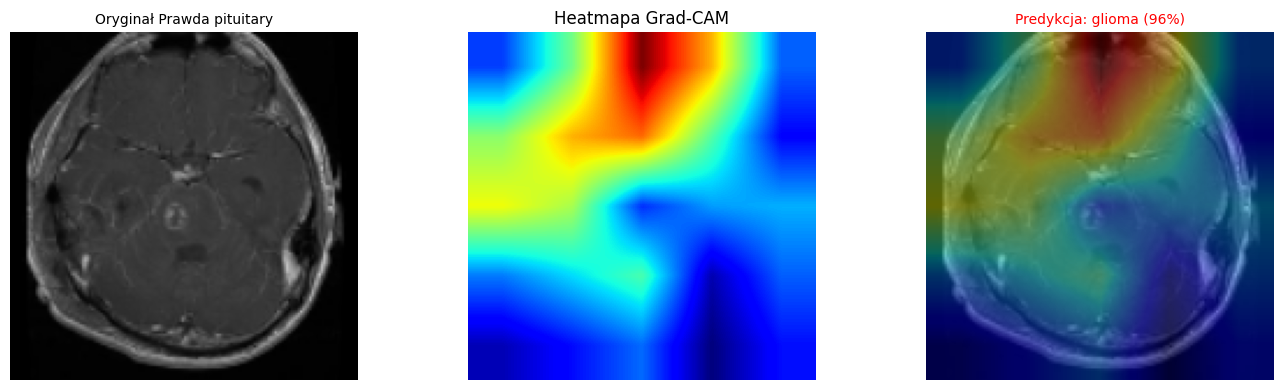

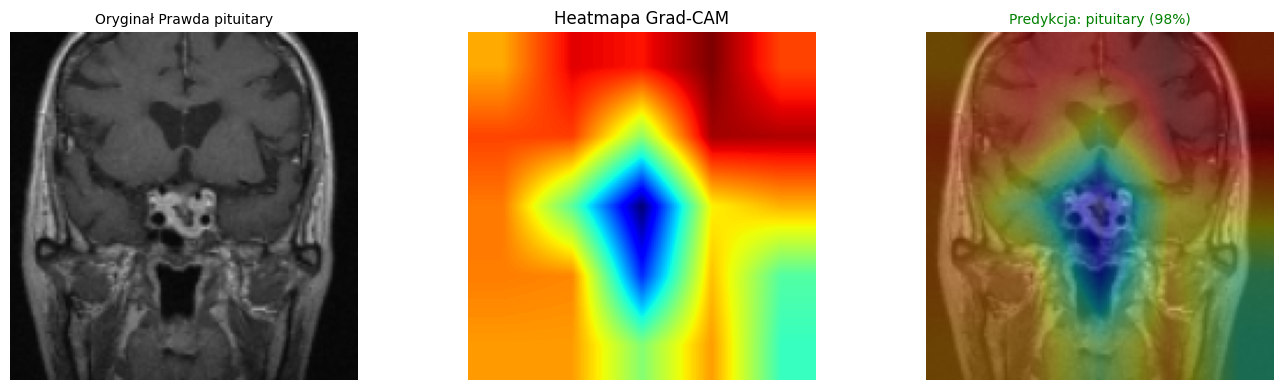

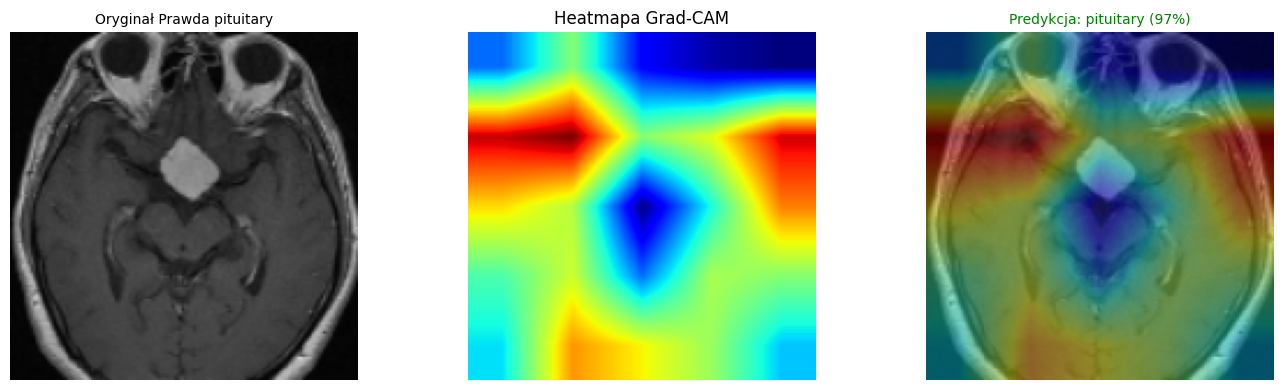

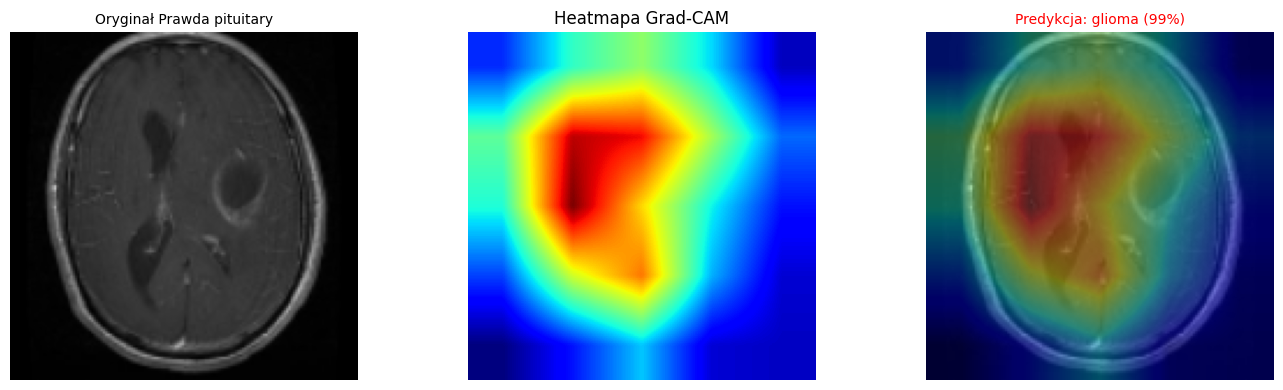

In [ ]:
# Grad-CAM dla modelu EfficientNet

last_conv_name_effNet = "top_conv"

sample_effNet_x, sample_effNet_y = next(iter(batched_test_ds_effNet))

for i in range(4):
  img = sample_effNet_x[i]
  true_class = int(np.argmax(sample_effNet_y[1].numpy()))

  img_batch = tf.expand_dims(img, axis=0)

  heatmap, pred_class, confidence = make_gradcam_heatmap(
      model_effNet, img_batch, last_conv_name_effNet
  )

  show_gradcam(
      img.numpy() / 255.0,heatmap, true_class, pred_class, confidence, class_names
  )